In [188]:
!pip install pandas-profiling numpy matplotlib seaborn --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-learn 1.6.1 requires joblib>=1.2.0, but you have joblib 1.1.1 which is incompatible.


In [189]:
!pip install opendatasets scikit-learn jovian --quiet --upgrade


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires joblib~=1.1.0, but you have joblib 1.4.2 which is incompatible.


In [190]:
import opendatasets as od
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib
import jovian
import os
%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'


# Downloading and loading the dataset

In [191]:
od.download('https://www.kaggle.com/datasets/asinow/car-price-dataset')


Skipping, found downloaded files in "./car-price-dataset" (use force=True to force download)


In [192]:
df = pd.read_csv('/content/car-price-dataset/car_price_dataset.csv')
df

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867
...,...,...,...,...,...,...,...,...,...,...
9995,Kia,Optima,2004,3.7,Diesel,Semi-Automatic,5794,2,4,8884
9996,Chevrolet,Impala,2002,1.4,Electric,Automatic,168000,2,1,6240
9997,BMW,3 Series,2010,3.0,Petrol,Automatic,86664,5,1,9866
9998,Ford,Explorer,2002,1.4,Hybrid,Automatic,225772,4,1,4084




#Converting released years to years used



In [193]:
df["Years_used"] = 2025 - df.Year

In [194]:
df = df.drop('Year', axis=1)

In [195]:
df.isna().sum()

,0
Brand,0
Model,0
Engine_Size,0
Fuel_Type,0
Transmission,0
Mileage,0
Doors,0
Owner_Count,0
Price,0
Years_used,0


In [196]:
df

,Brand,Model,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price,Years_used
0,Kia,Rio,4.2,Diesel,Manual,289944,3,5,8501,5
1,Chevrolet,Malibu,2.0,Hybrid,Automatic,5356,2,3,12092,13
2,Mercedes,GLA,4.2,Diesel,Automatic,231440,4,2,11171,5
3,Audi,Q5,2.0,Electric,Manual,160971,2,1,11780,2
4,Volkswagen,Golf,2.6,Hybrid,Semi-Automatic,286618,3,3,2867,22
...,...,...,...,...,...,...,...,...,...,...
9995,Kia,Optima,3.7,Diesel,Semi-Automatic,5794,2,4,8884,21
9996,Chevrolet,Impala,1.4,Electric,Automatic,168000,2,1,6240,23
9997,BMW,3 Series,3.0,Petrol,Automatic,86664,5,1,9866,15
9998,Ford,Explorer,1.4,Hybrid,Automatic,225772,4,1,4084,23


#Distribution of Car's price based on Brands

<ipython-input-197-4d66beb63752>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Brand", y="Price", palette="deep", data=df)


<Axes: title={'center': 'Distribution of Car price based on brands'}, xlabel='Brand', ylabel='Price'>

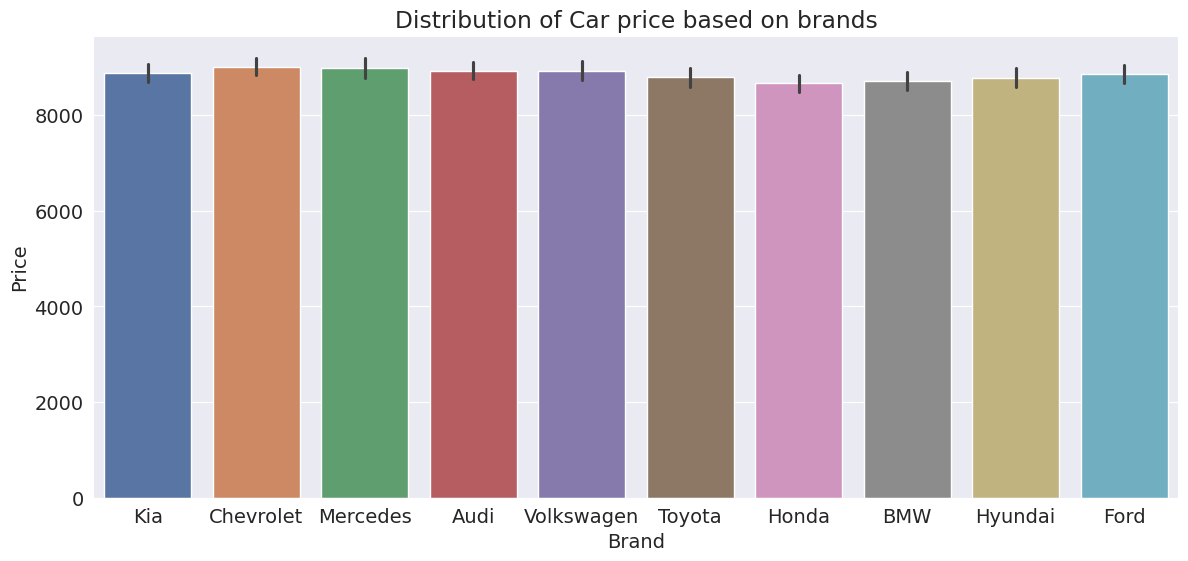

In [197]:
plt.figure(figsize=(14, 6))
plt.title("Distribution of Car price based on brands")
sns.barplot(x="Brand", y="Price", palette="deep", data=df)

#Entering inputs and target columns

In [198]:
input_cols = ['Brand', 'Model','Engine_Size','Fuel_Type','Transmission', 'Mileage','Doors','Owner_Count','Price','Years_used']

In [199]:
target_col = ['Price']

In [200]:
input=df[input_cols]
target=df[target_col]

#Identifying Numerical and Categorical columns

In [201]:
numeric_cols = input.select_dtypes(include=np.number).columns.tolist()
categorical_cols = input.select_dtypes('object').columns.tolist()


#Scaling the numerical columns for easy processing

In [202]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(input[numeric_cols])


In [203]:
input[numeric_cols] = scaler.transform(input[numeric_cols])


In [204]:
input[numeric_cols]

,Engine_Size,Mileage,Doors,Owner_Count,Price,Years_used
0,1.043657,1.630075,-0.447821,1.412122,-0.113083,-1.226021
1,-0.870607,-1.666895,-1.348689,0.006256,1.040674,-0.066156
2,1.043657,0.952303,0.453046,-0.696677,0.744764,-1.226021
3,-0.870607,0.135915,-1.348689,-1.399610,0.940431,-1.660970
4,-0.348535,1.591543,-0.447821,0.006256,-1.923238,1.238692
...,...,...,...,...,...,...
9995,0.608597,-1.661821,-1.348689,0.709189,0.009971,1.093709
9996,-1.392679,0.217346,-1.348689,-1.399610,-0.839523,1.383676
9997,-0.000487,-0.724937,1.353914,-1.399610,0.325479,0.223810
9998,-1.392679,0.886638,0.453046,-1.399610,-1.532226,1.383676


#Encoding the categorical columns for easy processing

In [205]:
from sklearn.preprocessing import OneHotEncoder

In [206]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [207]:
encoder.fit(input[categorical_cols])


OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [208]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

In [209]:
input[encoded_cols] = encoder.transform(input[categorical_cols])


#This is how now the training input data looks

In [210]:
input = input[numeric_cols + encoded_cols]
input

,Engine_Size,Mileage,Doors,Owner_Count,Price,Years_used,Brand_Audi,Brand_BMW,Brand_Chevrolet,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Kia,Brand_Mercedes,Brand_Toyota,Brand_Volkswagen,Model_3 Series,Model_5 Series,Model_A3,Model_A4,Model_Accord,Model_C-Class,Model_CR-V,Model_Camry,Model_Civic,Model_Corolla,Model_E-Class,Model_Elantra,Model_Equinox,Model_Explorer,Model_Fiesta,Model_Focus,Model_GLA,Model_Golf,Model_Impala,Model_Malibu,Model_Optima,Model_Passat,Model_Q5,Model_RAV4,Model_Rio,Model_Sonata,Model_Sportage,Model_Tiguan,Model_Tucson,Model_X5,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual,Transmission_Semi-Automatic
0,1.043657,1.630075,-0.447821,1.412122,-0.113083,-1.226021,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.870607,-1.666895,-1.348689,0.006256,1.040674,-0.066156,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,1.043657,0.952303,0.453046,-0.696677,0.744764,-1.226021,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.870607,0.135915,-1.348689,-1.399610,0.940431,-1.660970,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,-0.348535,1.591543,-0.447821,0.006256,-1.923238,1.238692,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.608597,-1.661821,-1.348689,0.709189,0.009971,1.093709,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
9996,-1.392679,0.217346,-1.348689,-1.399610,-0.839523,1.383676,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
9997,-0.000487,-0.724937,1.353914,-1.399610,0.325479,0.223810,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
9998,-1.392679,0.886638,0.453046,-1.399610,-1.532226,1.383676,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


#Now lets split the data into training and testing

In [211]:
from sklearn.model_selection import train_test_split

In [212]:
X_train, X_test, y_train, y_test = train_test_split(input, target ,
                                   random_state=104,
                                   test_size=0.25,
                                   shuffle=True)

#Choosing the given regression model

In [214]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=0, oob_score=True)
model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(oob_score=True, random_state=0)

#Lets import the functions needed to check the models performance

In [215]:
from sklearn.metrics import mean_squared_error,r2_score

In [216]:
predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
print(f'Mean Squared Error: {mse}')



Mean Squared Error: 74.10882464000032


#Now check with linear regression

In [217]:
from sklearn.linear_model import LinearRegression
model1 = LinearRegression()
model1.fit(X_train, y_train)

predictions_linear = model1.predict(X_test)

mse_linear = mean_squared_error(y_test, predictions_linear)
print(f'Mean Squared Error: {mse_linear}')

Mean Squared Error: 2.7097444250502124e-23
